<a href="https://colab.research.google.com/github/nawfalalima2006-boop/Decodelab-Project-2/blob/main/Decodelab_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("/content/sample_data/creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
df.shape

(15936, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15936 entries, 0 to 15935
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    15936 non-null  int64  
 1   V1      15936 non-null  float64
 2   V2      15936 non-null  float64
 3   V3      15936 non-null  float64
 4   V4      15936 non-null  float64
 5   V5      15936 non-null  float64
 6   V6      15936 non-null  float64
 7   V7      15936 non-null  float64
 8   V8      15936 non-null  float64
 9   V9      15936 non-null  float64
 10  V10     15936 non-null  float64
 11  V11     15936 non-null  float64
 12  V12     15936 non-null  float64
 13  V13     15936 non-null  float64
 14  V14     15936 non-null  float64
 15  V15     15936 non-null  float64
 16  V16     15936 non-null  float64
 17  V17     15936 non-null  float64
 18  V18     15936 non-null  float64
 19  V19     15936 non-null  float64
 20  V20     15936 non-null  float64
 21  V21     15936 non-null  float64
 22

In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.duplicated().sum()

np.int64(53)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(15883, 31)

In [12]:
df["Class"].value_counts()

,count
Class,
0.000000,15809
1.000000,73
0.004581,1


In [13]:
(df["Class"].value_counts(normalize=True) * 100).round(2)

,proportion
Class,
0.000000,99.53
1.000000,0.46
0.004581,0.01


In [14]:
df["Class"].unique()

array([0.        , 1.        , 0.00458111])

In [15]:
# Keep only valid classes
df = df[df["Class"].isin([0, 1])]

# Convert to integer
df["Class"] = df["Class"].astype(int)

# Verify
print(df["Class"].unique())

[0 1]


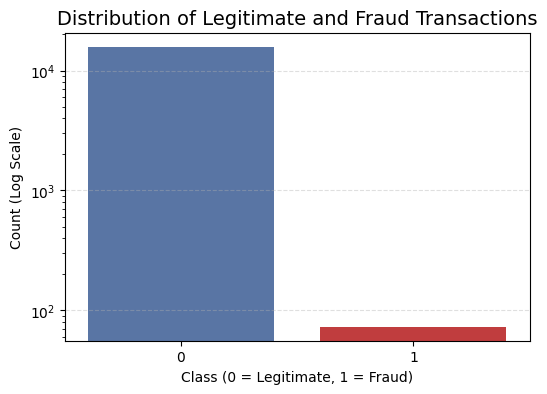

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
      data=df,
      x="Class",
      hue="Class",
      palette={0:"#4C72B0", 1:"#D62728"},
      legend=False
      )
plt.yscale("log")
plt.title("Distribution of Legitimate and Fraud Transactions", fontsize=14)
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count (Log Scale)")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [17]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
 )

In [19]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [20]:
baseline_pred = baseline_model.predict(X_test)

In [21]:
from sklearn.metrics import (
      accuracy_score,
      precision_score,
      recall_score,
      roc_auc_score
)
print("Accuracy :", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall   :", recall_score(y_test, baseline_pred))
print("ROC-AUC  :", roc_auc_score(y_test, baseline_pred))


Accuracy : 0.9977966635190432
Precision: 0.8333333333333334
Recall   : 0.6666666666666666
ROC-AUC  : 0.8330170777988614


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, baseline_pred)

print(cm)

[[3160    2]
 [   5   10]]


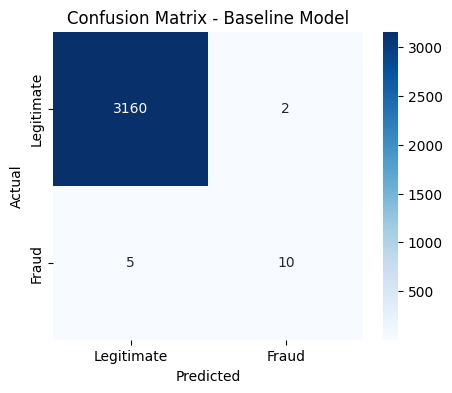

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")

plt.show()



In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3162
           1       0.83      0.67      0.74        15

    accuracy                           1.00      3177
   macro avg       0.92      0.83      0.87      3177
weighted avg       1.00      1.00      1.00      3177



In [25]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    12647
1       58
Name: count, dtype: int64


In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42,k_neighbors=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [27]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    12647
1    12647
Name: count, dtype: int64


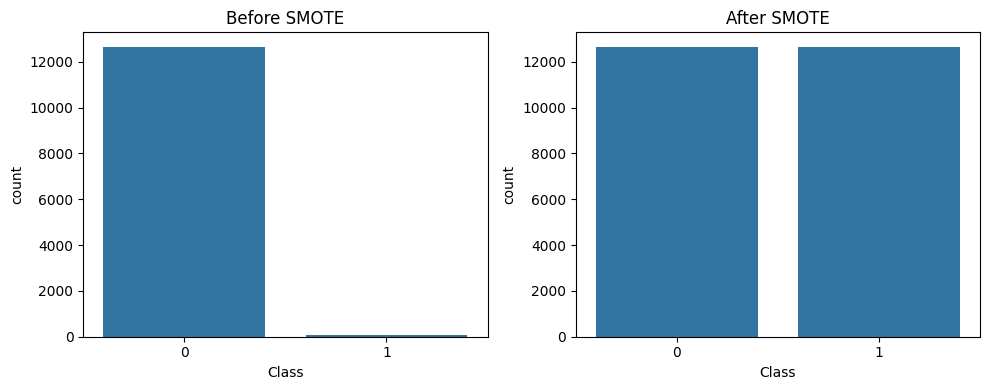

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [30]:
from imblearn.pipeline import Pipeline

In [31]:
logistic_pipeline = Pipeline([
      ("scaler", StandardScaler()),
          ("smote", SMOTE(random_state=42)),
              ("classifier", LogisticRegression(max_iter=1000, random_state=42))
              ])


In [32]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [33]:
lr_pred = logistic_pipeline.predict(X_test)

In [34]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_pred))

Accuracy : 0.9918161787850173
Precision: 0.34285714285714286
Recall   : 0.8
ROC-AUC  : 0.8963630613535737


In [35]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3162
           1       0.34      0.80      0.48        15

    accuracy                           0.99      3177
   macro avg       0.67      0.90      0.74      3177
weighted avg       1.00      0.99      0.99      3177



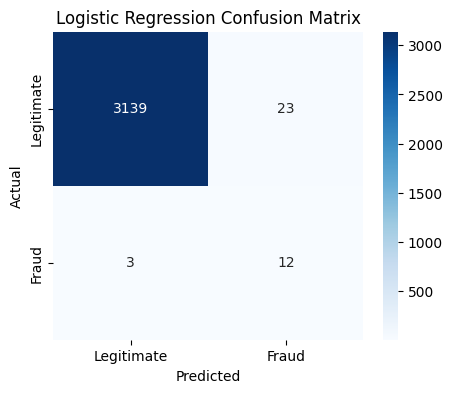

In [36]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
    )
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

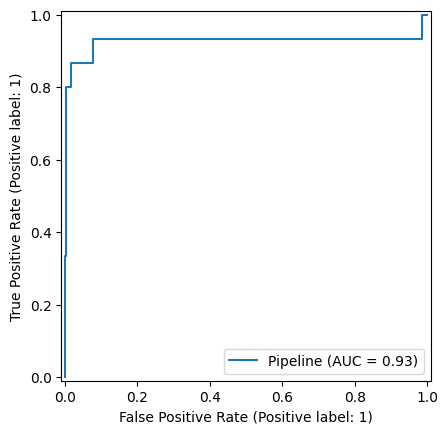

In [37]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    logistic_pipeline,
        X_test,
            y_test
            )

plt.show()

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
            ("classifier", RandomForestClassifier(random_state=42))
            ])

In [39]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

In [40]:
rf_pred = rf_pipeline.predict(X_test)

In [41]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_pred))

Accuracy : 0.9990557129367328
Precision: 0.9285714285714286
Recall   : 0.8666666666666667
ROC-AUC  : 0.9331752055660973


In [42]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3162
           1       0.93      0.87      0.90        15

    accuracy                           1.00      3177
   macro avg       0.96      0.93      0.95      3177
weighted avg       1.00      1.00      1.00      3177



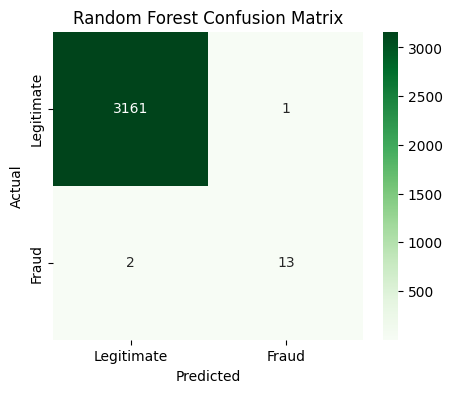

In [43]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [54]:
from sklearn.model_selection import GridSearchCV

In [50]:
param_grid = {
      "classifier__n_estimators": [100],
          "classifier__max_depth": [None, 10],
              "classifier__min_samples_split": [2, 5]
}

In [51]:
grid_search = GridSearchCV(
      rf_pipeline,
          param_grid=param_grid,
              cv=3,
                  scoring="recall",
                      n_jobs=-1

)


In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100],
        "classifier__max_depth": [10, None]
        }
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

In [65]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, None],
                         'classifier__n_estimators': [100]},
             scoring='recall')

In [70]:
print(hasattr(grid_search, "best_params_"))

True


In [71]:
print(grid_search.best_params_)

{'classifier__max_depth': 10, 'classifier__n_estimators': 100}


In [72]:
best_model = grid_search.best_estimator_

In [73]:
best_pred = best_model.predict(X_test)

In [74]:
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_pred))

Precision: 0.9285714285714286
Recall: 0.8666666666666667
ROC-AUC: 0.9331752055660973


In [75]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3162
           1       0.93      0.87      0.90        15

    accuracy                           1.00      3177
   macro avg       0.96      0.93      0.95      3177
weighted avg       1.00      1.00      1.00      3177



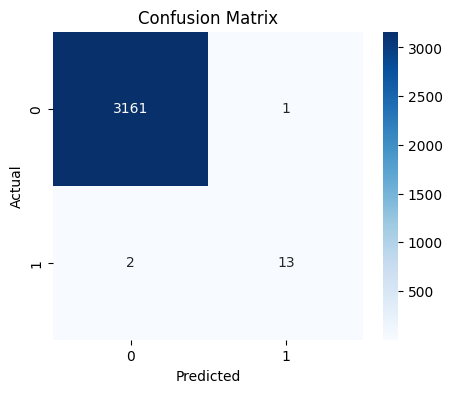

In [76]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [78]:
results = pd.DataFrame({
  "Model":["Logistic Regression","Random Forest"],
  "Precision":[precision_score(y_test, lr_pred), precision_score(y_test, best_pred)],
  "Recall":[recall_score(y_test, lr_pred), recall_score(y_test, best_pred)],
  "ROC-AUC":[roc_auc_score(y_test, lr_pred), roc_auc_score(y_test, best_pred)]
  })

results


,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.342857,0.800000,0.896363
1,Random Forest,0.928571,0.866667,0.933175
